<a href="https://colab.research.google.com/github/fischera715/Firm_Profitability_Drivers-Dataset/blob/main/Firm_Profitability_Drivers_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Appendix

In [ ]:
install.packages("BDEsize")
library(BDEsize)

install.packages("pwr")
library(pwr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
pwr.anova.test(k=8, f=0.25, sig.level=0.05, power=0.8)


     Balanced one-way analysis of variance power calculation 

              k = 8
              n = 29.59154
              f = 0.25
      sig.level = 0.05
          power = 0.8

NOTE: n is number in each group


In [ ]:
data <- read.csv("https://raw.githubusercontent.com/fischera715/DSA503-Final-Project/main/ratios_1_final.csv")

data$log_ROA <- log(abs(data$Return.on.assets) + 1)

head(data)

,Name,BSE.Code,NSE.Code,Industry,Current.Price,Market.Capitalization,Price.to.Earning,Dividend.yield,Price.to.book.value,Return.on.assets,⋯,Change.in.FII.holding,Change.in.DII.holding,DII.holding,Book.value.preceding.year,Return.on.capital.employed.preceding.year,Return.on.assets.preceding.year,Return.on.equity.preceding.year,Number.of.Shareholders.preceding.quarter,join_key,log_ROA
,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,20 Microns,533022,20MICRONS,Mining / Minerals / Metals,225.65,796.25,13.84,0.57,2.30,10.35,⋯,0.01,0.00,0.00,83.20,19.27,8.10,15.34,20546,533022.0_20MICRONS,2.429218
2,21st Cent. Mgmt.,526921,21STCENMGM,Finance & Investments,70.44,73.96,2.30,3.54,1.39,64.72,⋯,0.00,0.00,0.00,18.87,-43.10,-38.53,-62.72,6333,526921.0_21STCENMGM,4.185403
3,360 ONE,542772,360ONE,Finance & Investments,997.60,36199.65,45.05,1.63,10.36,6.11,⋯,0.74,-0.53,8.34,87.67,13.33,6.00,21.41,42622,542772.0_360ONE,1.961502
4,3B Blackbio,532067,__NA__,Healthcare,1184.50,1016.66,31.66,0.21,4.54,13.89,⋯,-0.41,0.71,1.89,228.05,19.06,12.77,16.00,10088,532067.0___NA__,2.700690
5,3C IT Solutions,544190,__NA__,Computers - Software - Medium / Small,44.10,26.55,23.30,0.00,NA,3.59,⋯,NA,NA,0.00,NA,29.33,4.19,53.37,NA,544190.0___NA__,1.523880
6,3i Infotech,532628,3IINFOLTD,Computers - Software - Medium / Small,36.75,622.03,NA,0.00,2.12,-8.99,⋯,0.21,-0.02,10.15,38.16,2.59,0.31,0.45,280315,532628.0_3IINFOLTD,2.301585


In [ ]:
colnames(data)

[1] "Name"                                     
 [2] "BSE.Code"                                 
 [3] "NSE.Code"                                 
 [4] "Industry"                                 
 [5] "Current.Price"                            
 [6] "Market.Capitalization"                    
 [7] "Price.to.Earning"                         
 [8] "Dividend.yield"                           
 [9] "Price.to.book.value"                      
[10] "Return.on.assets"                         
[11] "Debt.to.equity"                           
[12] "Return.on.equity"                         
[13] "Promoter.holding"                         
[14] "Earnings.yield"                           
[15] "Pledged.percentage"                       
[16] "Industry.PE"                              
[17] "Enterprise.Value"                         
[18] "Number.of.equity.shares"                  
[19] "Book.value"                               
[20] "Inventory.turnover.ratio"                 
[21] "Quick.ratio"                              
[22] "Exports.percentage"                       
[23] "Piotroski.score"                          
[24] "G.Factor"                                 
[25] "Asset.Turnover.Ratio"                     
[26] "Financial.leverage"                       
[27] "Number.of.Shareholders"                   
[28] "Unpledged.promoter.holding"               
[29] "Return.on.invested.capital"               
[30] "Debtor.days"                              
[31] "Industry.PBV"                             
[32] "Credit.rating"                            
[33] "Working.Capital.Days"                     
[34] "Earning.Power"                            
[35] "Graham.Number"                            
[36] "Cash.Conversion.Cycle"                    
[37] "Days.Payable.Outstanding"                 
[38] "Days.Receivable.Outstanding"              
[39] "Days.Inventory.Outstanding"               
[40] "Public.holding"                           
[41] "FII.holding"                              
[42] "Change.in.FII.holding"                    
[43] "Change.in.DII.holding"                    
[44] "DII.holding"                              
[45] "Book.value.preceding.year"                
[46] "Return.on.capital.employed.preceding.year"
[47] "Return.on.assets.preceding.year"          
[48] "Return.on.equity.preceding.year"          
[49] "Number.of.Shareholders.preceding.quarter" 
[50] "join_key"                                 
[51] "log_ROA"

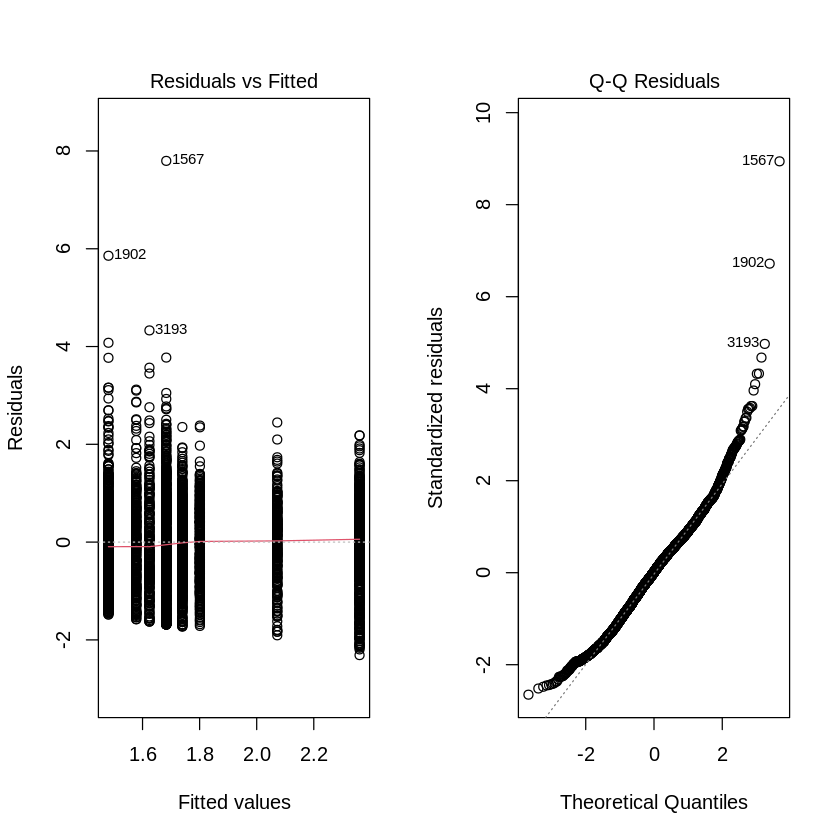

In [ ]:
data$A <- ifelse(data$Debt.to.equity > median(data$Debt.to.equity, na.rm=TRUE), "High", "Low")
data$B <- ifelse(data$Market.Capitalization > median(data$Market.Capitalization, na.rm=TRUE), "High", "Low")
data$C <- ifelse(data$Quick.ratio > median(data$Quick.ratio, na.rm=TRUE), "High", "Low")

model <- aov(log_ROA ~ A * B * C, data=data)

par(mfrow=c(1,2))
plot(model, which=1)
plot(model, which=2)

In [ ]:
data$A <- ifelse(data$Debt.to.equity > median(data$Debt.to.equity, na.rm=TRUE), "High", "Low")
data$B <- ifelse(data$Market.Capitalization > median(data$Market.Capitalization, na.rm=TRUE), "High", "Low")
data$C <- ifelse(data$Quick.ratio > median(data$Quick.ratio, na.rm=TRUE), "High", "Low")

model <- aov(log_ROA ~ A * B * C, data=data)
summary(model)

              Df Sum Sq Mean Sq F value   Pr(>F)    
A              1    113  112.85 148.241  < 2e-16 ***
B              1    200  199.75 262.403  < 2e-16 ***
C              1     12   12.28  16.130 6.02e-05 ***
A:B            1     37   36.61  48.089 4.69e-12 ***
A:C            1      2    2.10   2.764   0.0965 .  
B:C            1      2    1.61   2.117   0.1457    
A:B:C          1      4    3.56   4.677   0.0306 *  
Residuals   4254   3238    0.76                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
406 observations deleted due to missingness

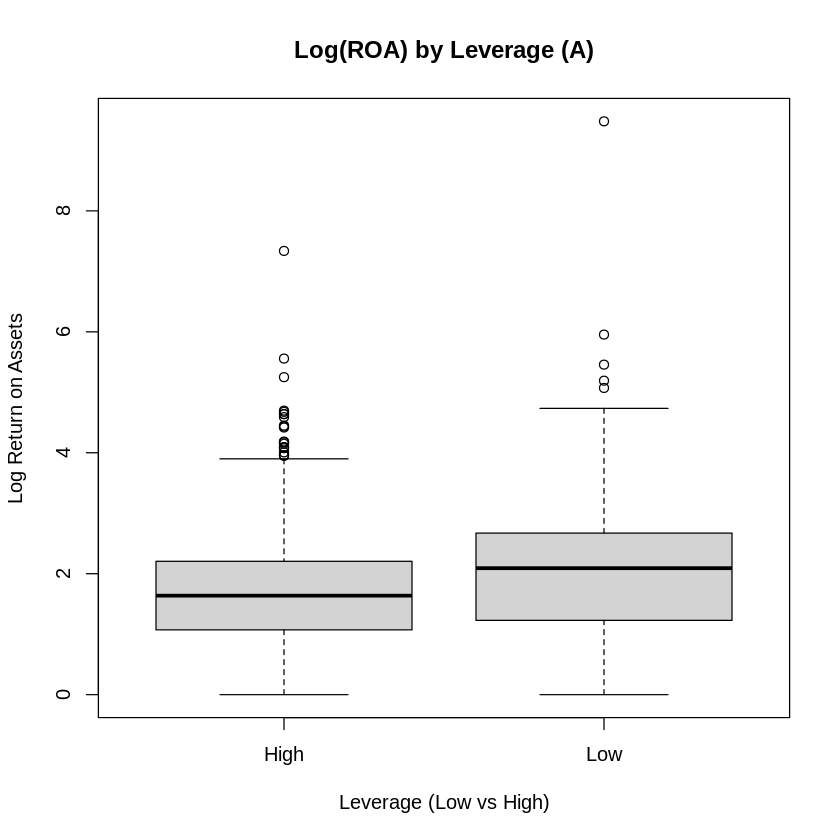

In [ ]:
boxplot(log_ROA ~ A, data=data,
        main="Log(ROA) by Leverage (A)",
        xlab="Leverage (Low vs High)",
        ylab="Log Return on Assets")

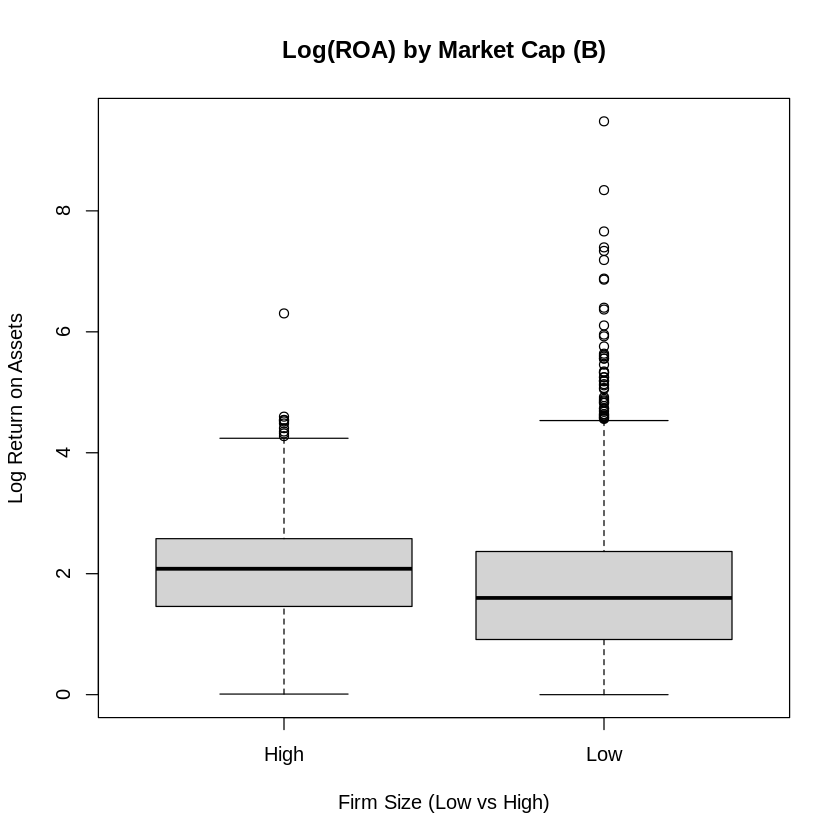

In [ ]:
boxplot(log_ROA ~ B, data=data,
        main="Log(ROA) by Market Cap (B)",
        xlab="Firm Size (Low vs High)",
        ylab="Log Return on Assets")

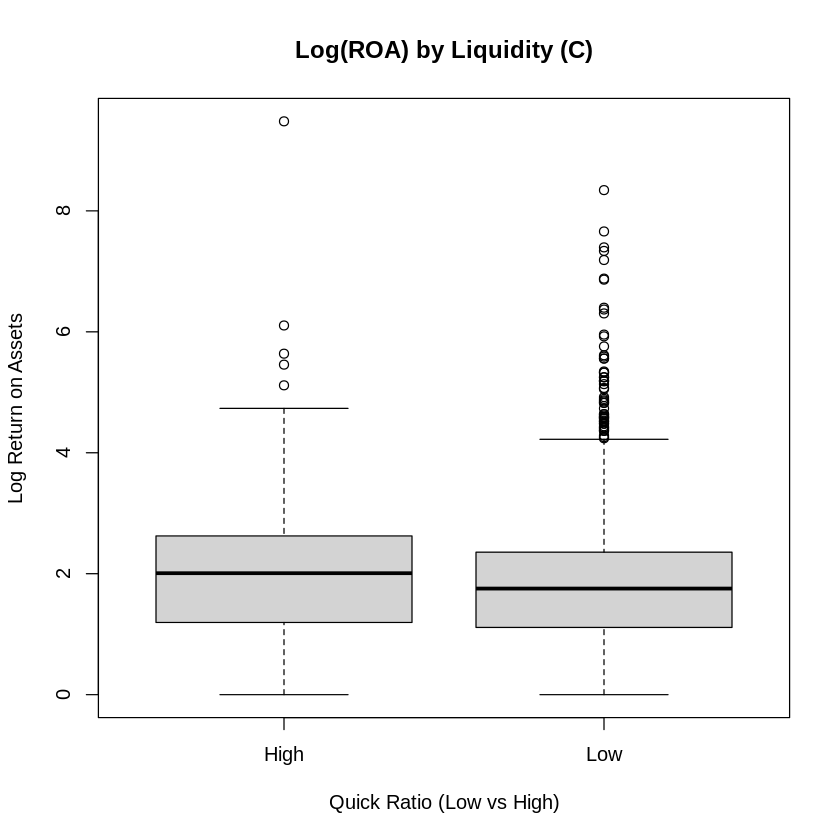

In [ ]:
boxplot(log_ROA ~ C, data=data,
        main="Log(ROA) by Liquidity (C)",
        xlab="Quick Ratio (Low vs High)",
        ylab="Log Return on Assets")

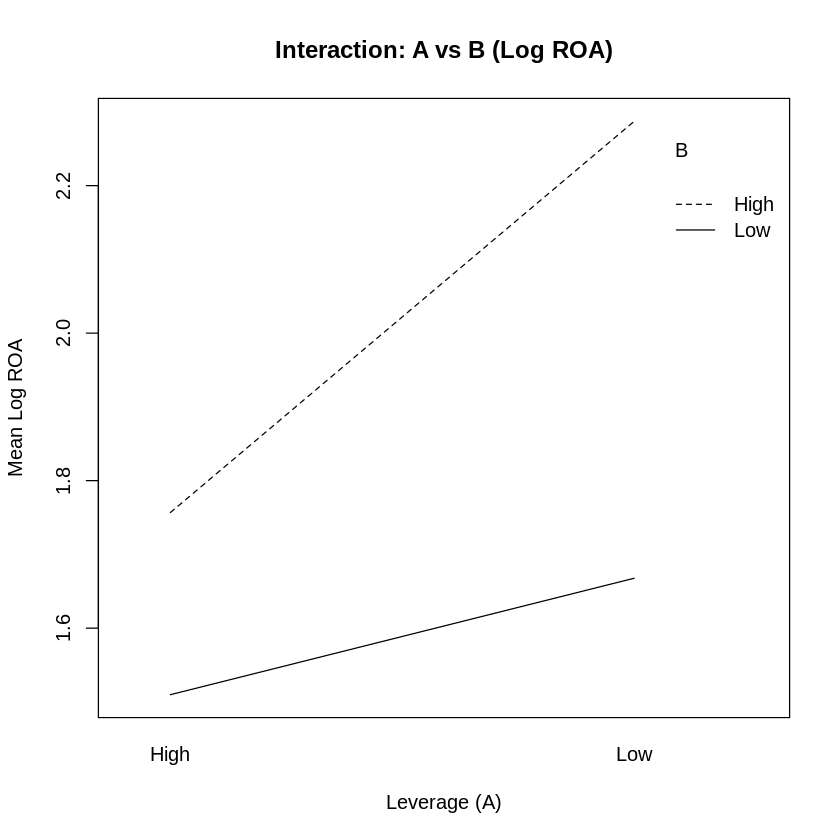

In [ ]:
with(data, interaction.plot(A, B, log_ROA,
                            fun=function(x) mean(x, na.rm = TRUE),
                            main="Interaction: A vs B (Log ROA)",
                            xlab="Leverage (A)",
                            ylab="Mean Log ROA"))

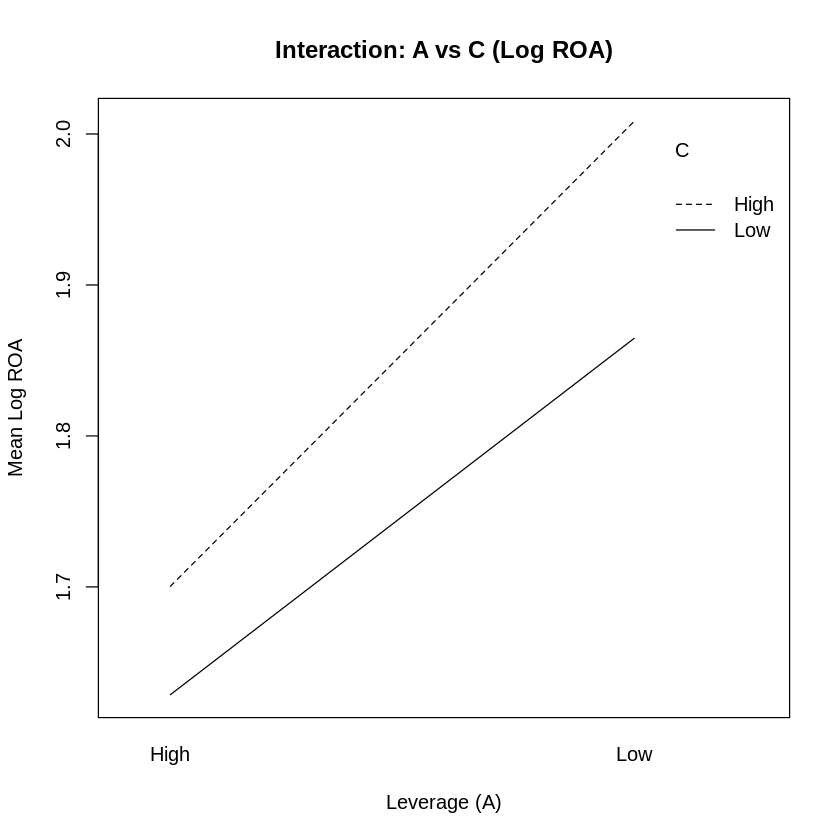

In [ ]:
with(data, interaction.plot(A, C, log_ROA,
                            fun=function(x) mean(x, na.rm = TRUE),
                            main="Interaction: A vs C (Log ROA)",
                            xlab="Leverage (A)",
                            ylab="Mean Log ROA"))

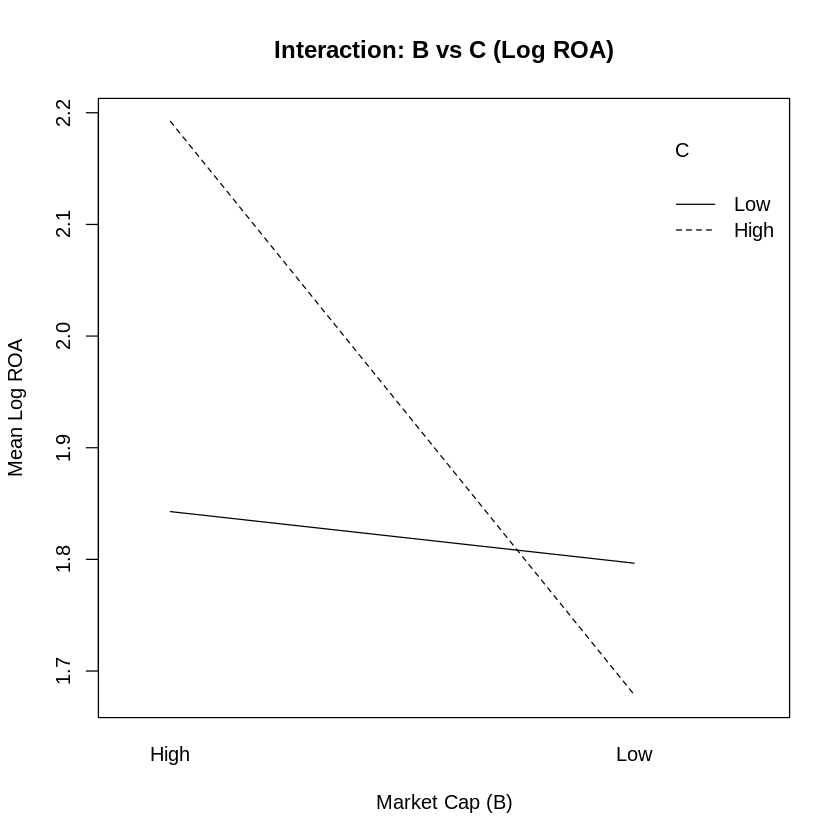

In [ ]:
with(data, interaction.plot(B, C, log_ROA,
                            fun=function(x) mean(x, na.rm = TRUE),
                            main="Interaction: B vs C (Log ROA)",
                            xlab="Market Cap (B)",
                            ylab="Mean Log ROA"))